# Projeto final

In [9]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import unicodedata 

In [10]:
df = pd.read_csv("dados_estudantes.csv")
df["turno"] = df["turno"].str.lower( ).str.strip( )
df["escola"] = df["escola"].str.lower( ).str.strip( )
df["nota"] = pd.to_numeric(df["nota"], errors = "coerce")
df["idade"]= pd.to_numeric(df["idade"],errors = "coerce")
df = df.dropna(subset = ["idade","nota"])

In [11]:
def remover_acentos(texto):
    if isinstance(texto,str):
        normalized = unicodedata.normalize('NFKD',texto)
        return normalized.encode('ascii','ignore').decode('utf-8')
    return texto
    
    

In [ ]:
for linha,coluna in df.items( ):
    df[coluna] = df[coluna].apply(remover_acentos)
print(df["turno"].unique( ))

In [14]:
maiores_de_idade = df[df["idade"]>=18]
print(maiores_de_idade)
turno_manha = df[(df["turno"]=="manhã")&(df["nota"]>=8)]
print(turno_manha)

Empty DataFrame
Columns: [id, idade, turno, escola, nota]
Index: []
     id  idade  turno   escola  nota
1     2   16.0  manhã  publica   8.0
13   14   17.0  manhã  pública   9.0
21   22   16.0  manhã  pública   8.0
26   27   17.0  manhã  publica   9.0
28   29   16.0  manhã  pública   8.0
33   34   16.0  manhã  pública   8.0
38   39   16.0  manhã  pública   8.0
43   44   17.0  manhã  pública   9.0
45   46   16.0  manhã  pública   8.0
50   51   17.0  manhã  pública   9.0
52   53   16.0  manhã  pública   8.0
57   58   17.0  manhã  pública   9.0
59   60   16.0  manhã  pública   8.0
64   65   17.0  manhã  pública   9.0
66   67   16.0  manhã  pública   8.0
71   72   17.0  manhã  pública   9.0
73   74   16.0  manhã  pública   8.0
78   79   17.0  manhã  pública   9.0
80   81   16.0  manhã  pública   8.0
85   86   17.0  manhã  pública   9.0
87   88   16.0  manhã  pública   8.0
92   93   17.0  manhã  pública   9.0
94   95   16.0  manhã  pública   8.0
99  100   17.0  manhã  pública   9.0


In [17]:
contagem_por_turno = df["turno"].value_counts( )
print(contagem_por_turno)
media_por_idade = df.groupby("idade")["nota"].mean( )
print(media_por_idade)

turno
manhã    43
tarde    28
noite    26
Name: count, dtype: int64
idade
15.0    6.682927
16.0    7.621951
17.0    9.000000
Name: nota, dtype: float64


# Gráfico 1: Nota Média por Idade

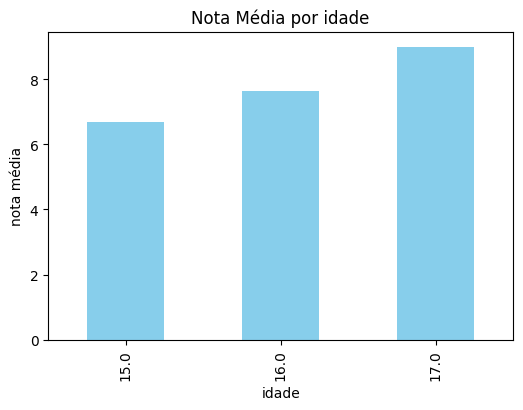

In [18]:
plt.figure(figsize = (6,4))
media_por_idade.plot(kind = "bar",color = "skyblue")
plt.title("Nota Média por idade")
plt.xlabel("idade")
plt.ylabel("nota média")
plt.show( )

# Gráfico 2: Histograma de Idades

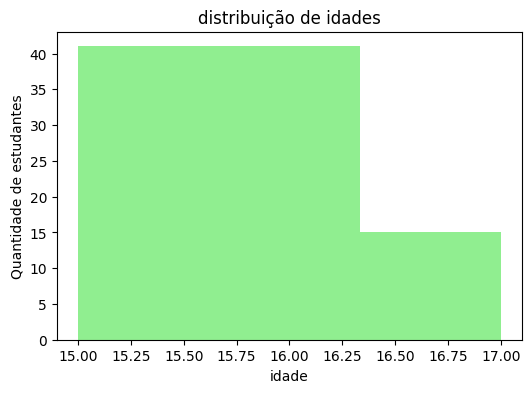

In [19]:
plt.figure(figsize = (6,4))
plt.hist(df["idade"],bins = 3,color = "lightgreen")
plt.title("distribuição de idades")
plt.xlabel("idade")
plt.ylabel("Quantidade de estudantes")
plt.show( )

# Gráfico 3: Dispersão entre idade e nota

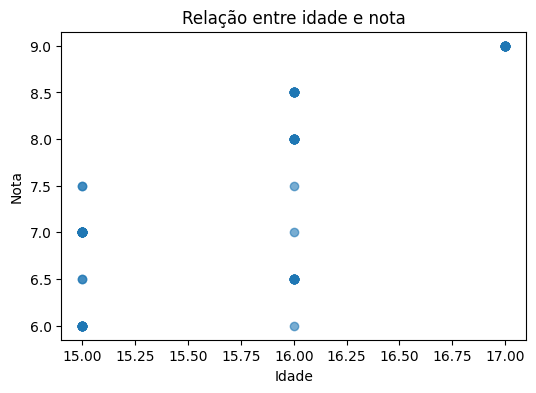

In [20]:
plt.figure(figsize = (6,4))
plt.scatter(df["idade"],df["nota"],alpha = 0.6)
plt.title("Relação entre idade e nota")
plt.xlabel("Idade")
plt.ylabel("Nota")
plt.show( )
